# Evaluation Expansion - Week 8

This notebook evaluates the Week 6 Random Forest and Week 7 LightGBM models.
It compares overall R2, MAPE, and MdAPE, then checks performance in different
house price bands.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import r2_score

PROJECT_ROOT = Path("..") if Path("../outputs").exists() else Path(".")
EVALUATION_DIR = PROJECT_ROOT / "08_evaluation"
WEEK6_FILE = PROJECT_ROOT / "outputs/week6_feature_engineering/test_predictions.csv"
WEEK7_FILE = PROJECT_ROOT / "outputs/week7_advanced_models/lightgbm_test_predictions.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs/week8_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for prediction_file in [WEEK6_FILE, WEEK7_FILE]:
    if not prediction_file.exists():
        raise FileNotFoundError(
            f"Missing {prediction_file}. Run the Week 6 and Week 7 notebooks first."
        )

## 1. Load the test predictions

In [2]:
week6 = pd.read_csv(WEEK6_FILE)
week7 = pd.read_csv(WEEK7_FILE)

week6 = week6[["ListingKey", "actual_close_price", "week6_prediction"]]
week6 = week6.rename(columns={
    "actual_close_price": "actual_price",
    "week6_prediction": "Random Forest",
})

week7 = week7[["ListingKey", "actual_price", "predicted_price"]]
week7 = week7.rename(columns={"predicted_price": "LightGBM"})

# Match the predictions by ListingKey.
predictions = week6.merge(
    week7,
    on="ListingKey",
    how="inner",
    suffixes=("_week6", "_week7"),
    validate="one_to_one",
)

# The actual prices should be the same in both files.
price_difference = (
    predictions["actual_price_week6"] - predictions["actual_price_week7"]
).abs()
assert price_difference.max() < 0.01

predictions["actual_price"] = predictions["actual_price_week6"]
predictions = predictions[
    ["ListingKey", "actual_price", "Random Forest", "LightGBM"]
]

print("Matched test rows:", len(predictions))
display(predictions.head())

Matched test rows: 11898


,ListingKey,actual_price,Random Forest,LightGBM
0,1170383150,1070000.0,8.700713e+05,7.092848e+05
1,1159931881,730000.0,6.530468e+05,6.466412e+05
2,1159541083,1300000.0,1.269033e+06,1.225891e+06
3,1159508997,1800000.0,1.548401e+06,1.706713e+06
4,1159278664,1383000.0,1.274087e+06,1.119657e+06


## 2. Calculate the overall metrics

- R2 shows how much price variation the model explains. Higher is better.
- MAPE is the average absolute percentage error. Lower is better.
- MdAPE is the median absolute percentage error. Lower is better.

In [3]:
def calculate_metrics(actual, predicted):
    percentage_error = np.abs((actual - predicted) / actual)
    return {
        "r2": r2_score(actual, predicted),
        "mape": percentage_error.mean(),
        "mdape": percentage_error.median(),
    }


models = ["Random Forest", "LightGBM"]
overall_rows = []

for model in models:
    overall_rows.append({
        "model": model,
        "price_band": "All homes",
        "number_of_homes": len(predictions),
        **calculate_metrics(predictions["actual_price"], predictions[model]),
    })

overall_metrics = pd.DataFrame(overall_rows)
display(overall_metrics.round(4))

,model,price_band,number_of_homes,r2,mape,mdape
0,Random Forest,All homes,11898,0.8669,0.1315,0.0829
1,LightGBM,All homes,11898,0.8758,0.1470,0.1042


## 3. Create house price bands

In [4]:
band_edges = [0, 500_000, 750_000, 1_000_000, 2_000_000, np.inf]
band_names = [
    "$500K or less",
    "$500K-$750K",
    "$750K-$1M",
    "$1M-$2M",
    "Over $2M",
]

predictions["price_band"] = pd.cut(
    predictions["actual_price"],
    bins=band_edges,
    labels=band_names,
    include_lowest=True,
)

display(predictions["price_band"].value_counts(sort=False).to_frame("number_of_homes"))

,number_of_homes
price_band,
$500K or less,1635
$500K-$750K,2527
$750K-$1M,2371
$1M-$2M,3746
Over $2M,1619


## 4. Compare model performance by price band

In [5]:
band_rows = []

for price_band in band_names:
    band_data = predictions[predictions["price_band"] == price_band]

    for model in models:
        percentage_error = np.abs(
            (band_data["actual_price"] - band_data[model])
            / band_data["actual_price"]
        )
        band_rows.append({
            "model": model,
            "price_band": price_band,
            "number_of_homes": len(band_data),
            "mape": percentage_error.mean(),
            "mdape": percentage_error.median(),
        })

band_metrics = pd.DataFrame(band_rows)
display(band_metrics.round(4))

,model,price_band,number_of_homes,mape,mdape
0,Random Forest,$500K or less,1635,0.1717,0.0822
1,LightGBM,$500K or less,1635,0.2101,0.1264
2,Random Forest,$500K-$750K,2527,0.1113,0.0641
3,LightGBM,$500K-$750K,2527,0.1356,0.0940
4,Random Forest,$750K-$1M,2371,0.1070,0.0672
5,LightGBM,$750K-$1M,2371,0.1231,0.0856
6,Random Forest,$1M-$2M,3746,0.1273,0.0932
7,LightGBM,$1M-$2M,3746,0.1341,0.1057
8,Random Forest,Over $2M,1619,0.1678,0.1339
9,LightGBM,Over $2M,1619,0.1660,0.1399


## 5. Summarize the main findings

In [6]:
mdape_table = band_metrics.pivot(
    index="price_band",
    columns="model",
    values="mdape",
).reindex(band_names)

best_band_rf = mdape_table["Random Forest"].idxmin()
best_band_lgbm = mdape_table["LightGBM"].idxmin()
worst_band_rf = mdape_table["Random Forest"].idxmax()
worst_band_lgbm = mdape_table["LightGBM"].idxmax()

print("Random Forest lowest MdAPE:", best_band_rf)
print("Random Forest highest MdAPE:", worst_band_rf)
print("LightGBM lowest MdAPE:", best_band_lgbm)
print("LightGBM highest MdAPE:", worst_band_lgbm)
print("Random Forest has the lower MdAPE in all five price bands.")

Random Forest lowest MdAPE: $500K-$750K
Random Forest highest MdAPE: Over $2M
LightGBM lowest MdAPE: $750K-$1M
LightGBM highest MdAPE: Over $2M
Random Forest has the lower MdAPE in all five price bands.


## 6. Save the metrics and charts

In [7]:
metrics_summary = pd.concat([overall_metrics, band_metrics], ignore_index=True)
metrics_summary.to_csv(EVALUATION_DIR / "metrics_summary.csv", index=False)

colors = ["#8da0cb", "#66c2a5"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

overall_plot = overall_metrics.set_index("model")
axes[0].bar(overall_plot.index, overall_plot["r2"], color=colors)
axes[0].set_title("Overall May 2026 Test R2")
axes[0].set_ylim(0, 1)
for index, value in enumerate(overall_plot["r2"]):
    axes[0].text(index, value + 0.02, f"{value:.3f}", ha="center")

mdape_plot = mdape_table * 100
x = np.arange(len(band_names))
width = 0.35
axes[1].bar(x - width / 2, mdape_plot["Random Forest"], width,
            label="Random Forest", color=colors[0])
axes[1].bar(x + width / 2, mdape_plot["LightGBM"], width,
            label="LightGBM", color=colors[1])
axes[1].set_title("MdAPE by House Price Band")
axes[1].set_ylabel("MdAPE (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(band_names, rotation=25, ha="right")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "week8_evaluation_results.png", dpi=160)
plt.close()

## Final result

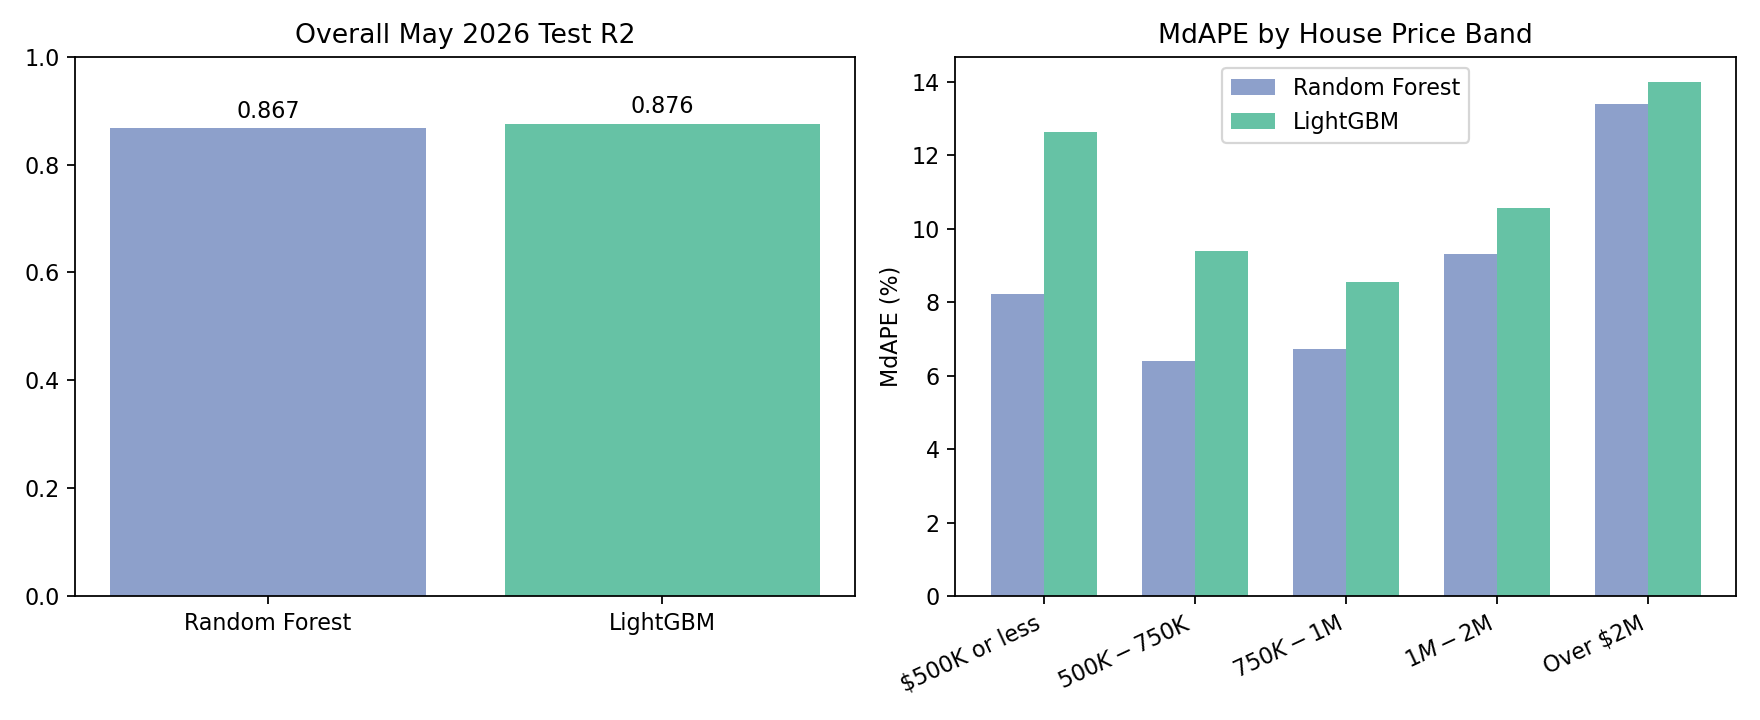

In [8]:
display(Image(filename=OUTPUT_DIR / "week8_evaluation_results.png"))

## Conclusion

LightGBM has the higher overall R2, but Random Forest has the lower overall MAPE
and MdAPE. Random Forest also has the lower MdAPE in every price band. The lowest
typical percentage errors are in the middle price bands, while both models have
their highest MdAPE for homes over $2 million.